# Tutorial 2 — CL24303 (CRE-II), MO2026
## Q2 & Q3 — Adsorption isotherm regression

| | |
|---|---|
| **Q2** | Langmuir isotherm for CO₂ on activated carbon and silica gel at 25 °C |
| **Q3** | Tóth and multi-site Langmuir isotherms for CO₂ and CH₄ on zeolite 13X at 298/308/323 K, then Δ*H*<sub>ads</sub> from a van 't Hoff plot |

Everything is non-linear least squares — the same objective Excel's Solver minimises,
here handed to `scipy.optimize.least_squares` (Trust-Region-Reflective), which is the
same class of gradient method as Solver's GRG Nonlinear.

Run top to bottom. Only `numpy`, `scipy`, `pandas` and `matplotlib` are needed.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares, brentq

plt.rcParams.update({'figure.dpi': 110, 'font.size': 10, 'axes.grid': True,
                     'grid.alpha': 0.3, 'axes.spines.top': False, 'axes.spines.right': False})
R = 8.314  # J mol^-1 K^-1
np.set_printoptions(suppress=True)

### A single goodness-of-fit helper

$$\mathrm{SSE}=\sum_i (q_{\text{calc},i}-q_{\exp,i})^2,\qquad
R^2 = 1-\frac{\mathrm{SSE}}{\mathrm{SST}},\qquad
\mathrm{AARD}=\frac{100}{N}\sum_i\left|\frac{q_{\text{calc},i}-q_{\exp,i}}{q_{\exp,i}}\right|$$

In [2]:
def gof(q_exp, q_calc, npar=0):
    """Goodness of fit. Relative error skips q_exp = 0 points."""
    q_exp, q_calc = np.asarray(q_exp, float), np.asarray(q_calc, float)
    res = q_calc - q_exp
    sse = float(res @ res)
    nz = q_exp > 0
    return {'SSE': sse,
            'R2': 1 - sse / float(((q_exp - q_exp.mean())**2).sum()),
            'RMSE': float(np.sqrt(sse / q_exp.size)),
            'AARD_%': float(100 * np.mean(np.abs(res[nz] / q_exp[nz])))}

---
# Q2 — Langmuir isotherm

$$\theta=\frac{q}{q_{max}}=\frac{Kp}{1+Kp}\qquad\Longrightarrow\qquad q=\frac{q_{max}Kp}{1+Kp}$$

Two parameters, $q_{max}$ and $K$, fitted by minimising SSE in $q$.

**Initial guess** comes from the linearised form $\dfrac{p}{q}=\dfrac{1}{q_{max}K}+\dfrac{p}{q_{max}}$,
so a straight line of $p/q$ vs $p$ gives $q_{max}=1/\text{slope}$ and $K=\text{slope}/\text{intercept}$.
The linearisation is only a *starting point* — it weights the low-pressure points wrongly,
so the final answer is the non-linear fit.

In [3]:
# CO2 adsorption at 25 C, JACS (1950) 72(3) 1153-1157.  p [mmHg], q [mmol/g]
carbon = np.array([[15.7, 0.791], [44.0, 1.141], [54.2, 1.223], [84.0, 1.416], [107.0, 1.532], [139.0, 1.646], [177.0, 1.769], [215.5, 1.872], [278.0, 2.006], [331.5, 2.105], [429.5, 2.254], [536.0, 2.373], [585.7, 2.454], [640.7, 2.479], [680.2, 2.51]]).T
silica = np.array([[11.1, 0.0564], [25.0, 0.1252], [43.5, 0.198], [71.4, 0.2986], [100.0, 0.385], [158.9, 0.5441], [227.5, 0.702], [304.2, 0.843], [387.0, 1.01], [468.0, 1.138], [569.0, 1.288], [677.8, 1.434], [775.0, 1.562]]).T
p_c, q_c = carbon
p_s, q_s = silica
print(f'activated carbon: {p_c.size} points,  silica: {p_s.size} points')

activated carbon: 15 points,  silica: 13 points


In [4]:
def langmuir(p, qmax, K):
    return qmax * K * p / (1 + K * p)

def fit_langmuir(p, q):
    # linear guess:  p/q = 1/(qmax*K) + p/qmax
    slope, intercept = np.polyfit(p, p / q, 1)
    guess = [1 / slope, slope / intercept]
    sol = least_squares(lambda x: langmuir(p, *x) - q, guess, bounds=(0, np.inf))
    return sol.x, guess

rows = []
fits = {}
for name, (p, q) in {'Activated carbon': (p_c, q_c), 'Silica gel': (p_s, q_s)}.items():
    (qmax, K), guess = fit_langmuir(p, q)
    fits[name] = (qmax, K)
    rows.append({'adsorbent': name, 'qmax [mmol/g]': qmax, 'K [1/mmHg]': K,
                 'qmax linear guess': guess[0], 'K linear guess': guess[1],
                 **gof(q, langmuir(p, qmax, K), 2)})

q2 = pd.DataFrame(rows).set_index('adsorbent')
q2.round(6)

,qmax [mmol/g],K [1/mmHg],qmax linear guess,K linear guess,SSE,R2,RMSE,AARD_%
adsorbent,,,,,,,,
Activated carbon,2.630372,0.014496,2.735178,0.012653,0.210980,0.948232,0.118597,6.970790
Silica gel,2.971437,0.001368,2.521308,0.001853,0.006941,0.997830,0.023107,6.970231


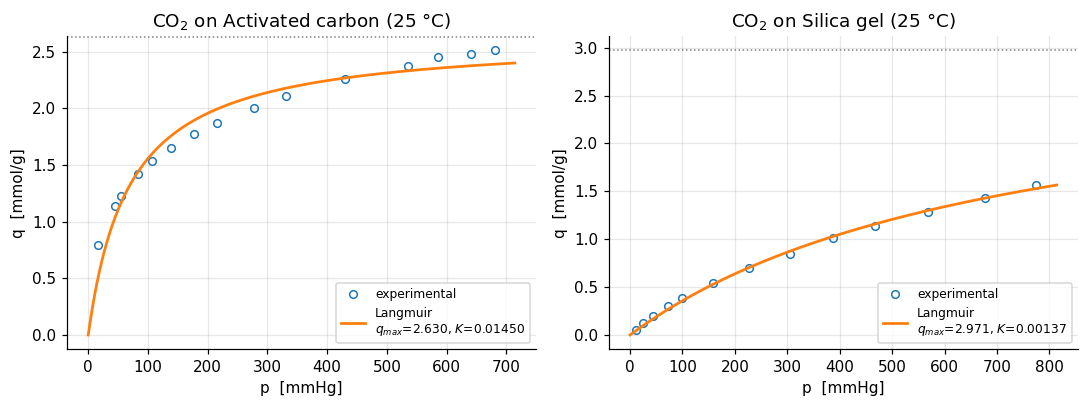

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.8))
for a, (name, (p, q)) in zip(ax, {'Activated carbon': (p_c, q_c), 'Silica gel': (p_s, q_s)}.items()):
    qmax, K = fits[name]
    pp = np.linspace(0, p.max() * 1.05, 400)
    a.plot(p, q, 'o', ms=5, mfc='none', label='experimental')
    a.plot(pp, langmuir(pp, qmax, K), '-', lw=1.8,
           label=f'Langmuir\n$q_{{max}}$={qmax:.3f}, $K$={K:.5f}')
    a.axhline(qmax, ls=':', c='0.5', lw=1)
    a.set(xlabel='p  [mmHg]', ylabel='q  [mmol/g]', title=f'CO$_2$ on {name} (25 °C)')
    a.legend(fontsize=8, loc='lower right')
fig.tight_layout()

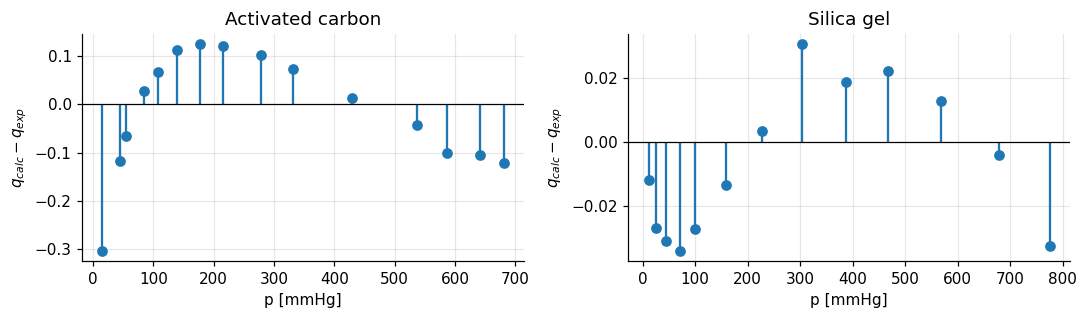

In [6]:
# residual plot - shows *where* the model fails
fig, ax = plt.subplots(1, 2, figsize=(10, 3), sharey=False)
for a, (name, (p, q)) in zip(ax, {'Activated carbon': (p_c, q_c), 'Silica gel': (p_s, q_s)}.items()):
    qmax, K = fits[name]
    a.stem(p, langmuir(p, qmax, K) - q, basefmt=' ')
    a.axhline(0, c='k', lw=0.8)
    a.set(xlabel='p [mmHg]', ylabel='$q_{calc}-q_{exp}$', title=name)
fig.tight_layout()

**Reading the Q2 result**

* **Silica gel** — $R^2\approx0.998$ and residuals scattered about zero: Langmuir is a
  genuinely good description. $Kp\ll1$ over the whole range, so the isotherm is still
  almost in its linear (Henry) region and $q_{max}$ is an extrapolation.
* **Activated carbon** — $R^2\approx0.948$ and the residuals are *systematic* (S-shaped,
  not random). Langmuir assumes one energetically uniform site type; activated carbon has a
  broad distribution of pore sizes and binding energies, so the real isotherm rises faster at
  low $p$ and flatter at high $p$ than any single-site Langmuir can. A heterogeneous form
  (Tóth, Freundlich, Sips) is required — which is exactly the motivation for Q3.
* Carbon binds CO₂ an order of magnitude more strongly ($K\approx0.0145$ vs
  $0.00137$ mmHg⁻¹) — at 100 mmHg the carbon is already ~59 % covered while the silica is
  only ~12 %.

---
# Q3 — Tóth and multi-site Langmuir on zeolite 13X

$$\textbf{Tóth:}\quad \frac{q}{q_{max}}=\frac{Kp}{\left[1+(Kp)^{n}\right]^{1/n}}
\qquad\qquad
\textbf{Multi-site Langmuir:}\quad \frac{q}{q_{max}}=Kp\left(1-\frac{q}{q_{max}}\right)^{a}$$

Both reduce to Langmuir at $n=1$ / $a=1$. Tóth's $n$ measures surface *heterogeneity*
($n<1$); the multi-site $a$ is the number of adsorption sites one molecule occupies.

**Fitting strategy.** $q_{max}$, $n$ and $a$ describe the *adsorbent–adsorbate pair* and are
taken temperature-independent, while $K$ carries all the temperature dependence
($K=K_0e^{-\Delta H_{ads}/RT}$). So the three isotherms of one gas are fitted
**simultaneously** with shared $q_{max}, n$ (or $a$) and one $K$ per temperature —
5 parameters against ~60–90 points. Fitting each temperature independently would let
$q_{max}$ drift with $T$ and make the van 't Hoff plot meaningless.

In [7]:
# J. Chem. Eng. Data 2004, 49, 1095-1101.  P [MPa], q [mol/kg]
T_list = [298, 308, 323]
CH4 = {T: np.array(v).T for T, v in {298: [[0.0, 0.0], [0.00405, 0.024], [0.01203, 0.089], [0.0191, 0.131], [0.05515, 0.326], [0.125, 0.712], [0.165, 0.877], [0.21, 1.12], [0.306, 1.474], [0.345, 1.617], [0.425, 1.83], [0.631, 2.357], [0.819, 2.726], [1.07, 3.06], [1.18, 3.26], [1.41, 3.53], [1.72, 3.834], [1.89, 3.991], [2.175, 4.198], [2.61, 4.506], [2.985, 4.75], [3.365, 4.987], [3.56, 5.103], [3.745, 5.191], [3.745, 5.191], [4.26, 5.469], [4.725, 5.719]], 308: [[0.0, 0.0], [0.00525, 0.022], [0.01115, 0.064], [0.0204, 0.109], [0.04007, 0.21], [0.08516, 0.415], [0.135, 0.623], [0.135, 0.632], [0.19, 0.823], [0.28, 1.133], [0.31, 1.232], [0.35, 1.36], [0.445, 1.618], [0.585, 1.931], [0.585, 1.932], [0.695, 2.154], [0.78, 2.342], [0.875, 2.466], [1.11, 2.792], [1.48, 3.201], [1.7, 3.409], [1.79, 3.48], [2.17, 3.781], [2.53, 4.038], [2.535, 4.034], [2.84, 4.236], [3.64, 4.702], [4.015, 4.884], [4.49, 5.127], [4.72, 5.234]], 323: [[0.0, 0.0], [0.00603, 0.017], [0.01215, 0.052], [0.022, 0.09], [0.03302, 0.14], [0.04612, 0.196], [0.05505, 0.227], [0.0801, 0.312], [0.115, 0.432], [0.165, 0.59], [0.24, 0.731], [0.34, 1.009], [0.34, 1.009], [0.4, 1.193], [0.51, 1.423], [0.505, 1.395], [0.635, 1.653], [0.78, 1.929], [0.865, 2.077], [0.955, 2.211], [1.185, 2.545], [1.495, 2.89], [1.695, 3.067], [1.86, 3.169], [2.425, 3.577], [2.57, 3.67], [3.015, 3.933], [3.425, 4.199], [3.425, 4.2], [3.67, 4.341], [4.18, 4.585], [4.445, 4.706], [4.745, 4.83]]}.items()}
CO2 = {T: np.array(v).T for T, v in {298: [[0.0, 0.0], [0.00118, 1.147], [0.0061, 2.249], [0.02905, 3.659], [0.0861, 4.5], [0.16, 5.06], [0.31, 5.58], [0.525, 6.04], [1.015, 6.52], [1.015, 6.5], [1.445, 6.92], [1.935, 6.96], [2.28, 7.09], [2.66, 7.22], [3.2, 7.372]], 308: [[0.0, 0.0], [0.00126, 0.825], [0.00407, 1.458], [0.00905, 2.06], [0.01325, 2.4], [0.02007, 2.734], [0.04515, 3.38], [0.09503, 4.05], [0.16, 4.49], [0.22, 4.74], [0.28, 4.96], [0.37, 5.167], [0.485, 5.315], [0.57, 5.399], [0.7, 5.586], [0.875, 5.718], [0.875, 5.718], [1.015, 5.803], [1.2, 5.942], [1.505, 6.116], [1.83, 6.291], [2.235, 6.51], [2.5, 6.631], [2.86, 6.769], [3.065, 6.885], [3.065, 6.82], [3.365, 6.92]], 323: [[0.0, 0.0], [0.00106, 0.356], [0.00214, 0.529], [0.00501, 1.06], [0.00907, 1.43], [0.02423, 2.09], [0.0422, 2.49], [0.07503, 2.9], [0.145, 3.4], [0.27, 3.915], [0.39, 4.1], [0.545, 4.329], [0.705, 4.532], [0.85, 4.74], [1.01, 4.82], [1.175, 4.93], [1.455, 5.2], [1.72, 5.24], [2.125, 5.43], [2.695, 5.62], [3.395, 5.762]]}.items()}
gases = {'CO2': CO2, 'CH4': CH4}
for g, s in gases.items():
    print(g, {T: s[T].shape[1] for T in T_list})

CO2 {298: 15, 308: 27, 323: 21}
CH4 {298: 27, 308: 30, 323: 33}


## Q3a — Tóth isotherm

In [8]:
def toth(p, qmax, K, n):
    Kp = K * p
    return qmax * Kp / (1 + Kp**n)**(1 / n)

def fit_toth(sets):
    """Simultaneous fit over all T:  x = [qmax, n, K_298, K_308, K_323]."""
    P = [sets[T][0] for T in T_list]
    Q = [sets[T][1] for T in T_list]

    def residual(x):
        qmax, n, Ks = x[0], x[1], x[2:]
        return np.concatenate([toth(P[i], qmax, Ks[i], n) - Q[i] for i in range(len(T_list))])

    guess = [max(q.max() for q in Q) * 1.15, 0.7] + [5.0] * len(T_list)
    lower = [0.0, 0.05] + [0.0] * len(T_list)
    sol = least_squares(residual, guess, bounds=(lower, np.inf), xtol=1e-14, ftol=1e-14)
    qmax, n, Ks = sol.x[0], sol.x[1], sol.x[2:]
    return qmax, n, dict(zip(T_list, Ks))

toth_par = {g: fit_toth(s) for g, s in gases.items()}
for g, (qmax, n, Ks) in toth_par.items():
    print(f'{g}:  qmax = {qmax:7.4f} mol/kg   n = {n:6.4f}   ' +
          '   '.join(f'K{T} = {Ks[T]:9.4f}' for T in T_list))

CO2:  qmax = 10.6208 mol/kg   n = 0.2442   K298 = 4655.1189   K308 = 2136.5790   K323 =  612.7113
CH4:  qmax = 10.0194 mol/kg   n = 0.6114   K298 =    0.8509   K308 =    0.6665   K323 =    0.5207


## Q3b — Multi-site Langmuir

Two things make this model awkward, and both need a deliberate choice.

**1. It is implicit in $q$.** $\theta=Kp(1-\theta)^{a}$ cannot be rearranged for $\theta$.
Two ways out:

* solve $\theta-Kp(1-\theta)^a=0$ numerically for every point (Brent's method — done below
  for plotting and for the $R^2$), or
* note that $\theta_{\exp}=q_{\exp}/q_{max}$ is *known*, so
  $p_{calc}=\theta/[K(1-\theta)^{a}]$ is **explicit** — and regress in the pressure
  direction, minimising $\sum(\ln p_{calc}-\ln p_{\exp})^2$.

The second is what the Excel sheet does (plain cell formulas, no iteration), so it is used
here too. The two routes agree on $a$ and $K$ to within ~1 %.

**2. $q_{max}$ and $a$ are strongly correlated.** Data alone barely distinguish
"few sites, weakly held" from "many sites, strongly held" — turned loose, Solver walks $a$
off to 20+ with an equally unphysical $q_{max}$. So $q_{max}$ is **fixed at the Tóth
saturation capacity**: the same gas on the same zeolite must saturate at the same loading,
whichever equation is used to describe the approach to saturation. Only $a$ and the three
$K$ are regressed.

In [9]:
def msl_theta(p, K, a):
    """Solve theta = K p (1-theta)^a  for theta in [0,1), point by point."""
    p = np.atleast_1d(np.asarray(p, float))
    out = np.zeros_like(p)
    for i, pi in enumerate(p):
        if pi > 0:
            out[i] = brentq(lambda t: t - K * pi * (1 - t)**a, 0.0, 1 - 1e-14, xtol=1e-14)
    return out

def msl(p, qmax, K, a):
    return qmax * msl_theta(p, K, a)

def fit_msl(sets, qmax, K0):
    """Fit a and K_i in the pressure direction. qmax fixed; p = 0 dropped (ln 0)."""
    P = [sets[T][0][sets[T][0] > 0] for T in T_list]
    TH = [sets[T][1][sets[T][0] > 0] / qmax for T in T_list]

    def residual(x):
        a, Ks = x[0], x[1:]
        return np.concatenate([np.log(TH[i] / (Ks[i] * (1 - TH[i])**a)) - np.log(P[i])
                               for i in range(len(T_list))])

    best = None
    for a0 in (1.5, 2.5, 4.0, 6.0):            # multistart - the objective is not convex
        sol = least_squares(residual, [a0] + [K0] * len(T_list),
                            bounds=([1.0] + [1e-9] * len(T_list), np.inf),
                            xtol=1e-14, ftol=1e-14)
        if best is None or sol.cost < best.cost:
            best = sol
    return best.x[0], dict(zip(T_list, best.x[1:]))

msl_par = {}
for g, s in gases.items():
    qmax = toth_par[g][0]                       # fixed from the Toth fit
    a, Ks = fit_msl(s, qmax, K0=100.0 if g == 'CO2' else 0.5)
    msl_par[g] = (qmax, a, Ks)
    print(f'{g}:  qmax = {qmax:7.4f} mol/kg (fixed)   a = {a:6.4f}   ' +
          '   '.join(f'K{T} = {Ks[T]:9.4f}' for T in T_list))

CO2:  qmax = 10.6208 mol/kg (fixed)   a = 6.0799   K298 =  193.4092   K308 =   80.5472   K323 =   22.9599
CH4:  qmax = 10.0194 mol/kg (fixed)   a = 2.1667   K298 =    0.6627   K308 =    0.5165   K323 =    0.3960


In [10]:
# goodness of fit of both models, in q, per temperature and overall
rows = []
for g, s in gases.items():
    qmT, n, KT = toth_par[g]
    qmM, a, KM = msl_par[g]
    for model, fn, pars in (('Toth', lambda p, T: toth(p, qmT, KT[T], n), None),
                            ('multi-site Langmuir', lambda p, T: msl(p, qmM, KM[T], a), None)):
        qe = np.concatenate([s[T][1] for T in T_list])
        qc = np.concatenate([fn(s[T][0], T) for T in T_list])
        r = {'gas': g, 'model': model, 'N': qe.size, **gof(qe, qc)}
        for T in T_list:
            r[f'R2 {T}K'] = gof(s[T][1], fn(s[T][0], T))['R2']
        rows.append(r)
pd.DataFrame(rows).set_index(['gas', 'model']).round(5)

N      SSE       R2     RMSE   AARD_%  R2 298K  \
gas model                                                                  
CO2 Toth                 63  0.53152  0.99811  0.09185  3.60305  0.99892   
    multi-site Langmuir  63  1.29341  0.99540  0.14328  4.44460  0.99556   
CH4 Toth                 90  0.15697  0.99944  0.04176  4.83318  0.99948   
    multi-site Langmuir  90  0.22184  0.99921  0.04965  3.25334  0.99904   

                         R2 308K  R2 323K  
gas model                                  
CO2 Toth                 0.99807  0.99650  
    multi-site Langmuir  0.99682  0.99128  
CH4 Toth                 0.99943  0.99936  
    multi-site Langmuir  0.99910  0.99943

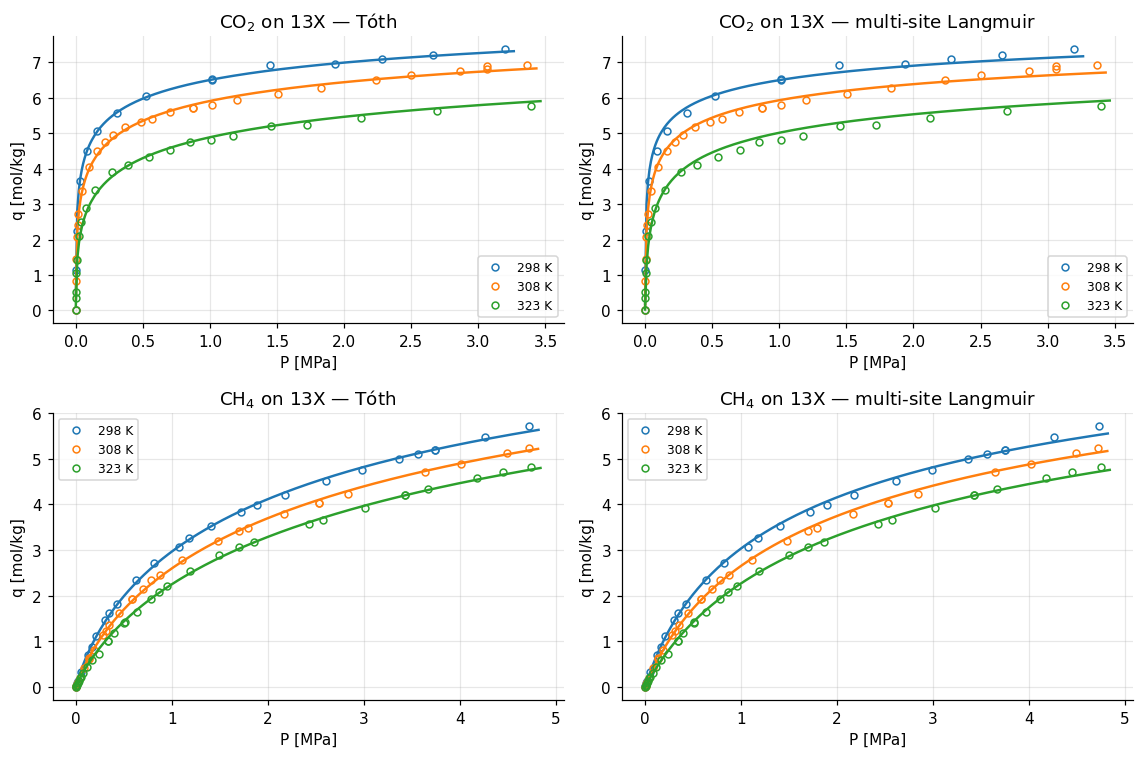

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(10.5, 7))
colors = {298: 'tab:blue', 308: 'tab:orange', 323: 'tab:green'}
for row, g in enumerate(['CO2', 'CH4']):
    s = gases[g]
    qmT, n, KT = toth_par[g]
    qmM, a, KM = msl_par[g]
    for col, (lbl, fn) in enumerate([('Tóth', lambda p, T: toth(p, qmT, KT[T], n)),
                                     ('multi-site Langmuir', lambda p, T: msl(p, qmM, KM[T], a))]):
        ax = axes[row, col]
        for T in T_list:
            p, q = s[T]
            pp = np.linspace(1e-4, p.max() * 1.02, 300)
            ax.plot(p, q, 'o', ms=4.5, mfc='none', color=colors[T], label=f'{T} K')
            ax.plot(pp, fn(pp, T), '-', lw=1.6, color=colors[T])
        ax.set(xlabel='P [MPa]', ylabel='q [mol/kg]',
               title=f'{"CO$_2$" if g=="CO2" else "CH$_4$"} on 13X — {lbl}')
        ax.legend(fontsize=8)
fig.tight_layout()

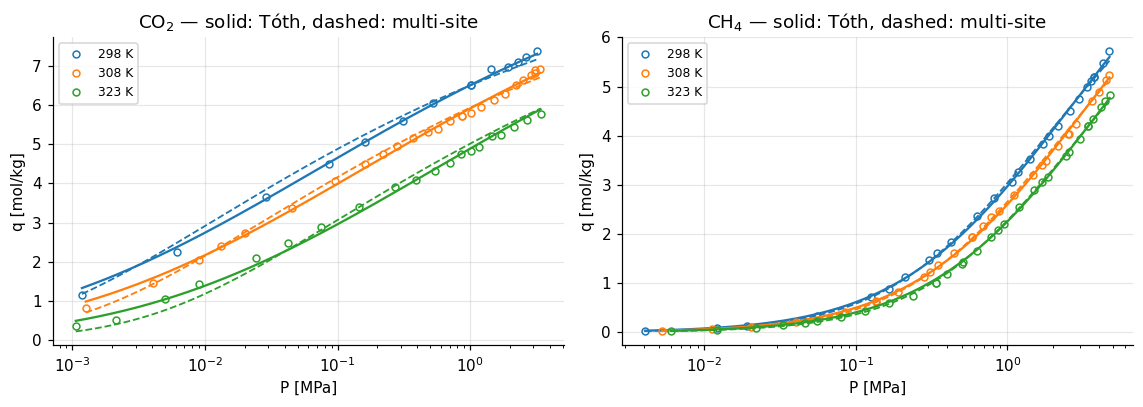

In [12]:
# log-pressure view: the low-pressure (Henry) region is where the models differ most
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8))
for ax, g in zip(axes, ['CO2', 'CH4']):
    s = gases[g]
    qmT, n, KT = toth_par[g]
    qmM, a, KM = msl_par[g]
    for T in T_list:
        p, q = s[T]
        m = p > 0
        pp = np.logspace(np.log10(p[m].min()), np.log10(p.max()), 300)
        ax.semilogx(p[m], q[m], 'o', ms=4.5, mfc='none', color=colors[T], label=f'{T} K')
        ax.semilogx(pp, toth(pp, qmT, KT[T], n), '-', lw=1.5, color=colors[T])
        ax.semilogx(pp, msl(pp, qmM, KM[T], a), '--', lw=1.2, color=colors[T])
    ax.set(xlabel='P [MPa]', ylabel='q [mol/kg]',
           title=f'{"CO$_2$" if g=="CO2" else "CH$_4$"} — solid: Tóth, dashed: multi-site')
    ax.legend(fontsize=8)
fig.tight_layout()

## Q3c — Heat of adsorption from the van 't Hoff plot

$$K = K_0\exp\!\left(-\frac{\Delta H_{ads}}{RT}\right)
\qquad\Longrightarrow\qquad
\ln K = \ln K_0 - \frac{\Delta H_{ads}}{R}\cdot\frac{1}{T}$$

A straight line of $\ln K$ against $1/T$ has **slope $=-\Delta H_{ads}/R$**, so
$\Delta H_{ads}=-R\times\text{slope}$. Three temperatures, two parameters — one degree of
freedom, so a high $R^2$ here confirms consistency rather than proving it.

In [13]:
def vant_hoff(Ks):
    T = np.array(T_list, float)
    x, y = 1 / T, np.log([Ks[T_] for T_ in T_list])
    slope, intercept = np.polyfit(x, y, 1)
    r2 = 1 - ((y - (slope * x + intercept))**2).sum() / ((y - y.mean())**2).sum()
    return {'slope': slope, 'lnK0': intercept, 'K0': np.exp(intercept),
            'dH_ads [kJ/mol]': -slope * R / 1000, 'R2': r2, 'x': x, 'y': y}

vh = {}
rows = []
for g in gases:
    vh[(g, 'Toth')] = vant_hoff(toth_par[g][2])
    vh[(g, 'multi-site Langmuir')] = vant_hoff(msl_par[g][2])
for (g, m), v in vh.items():
    rows.append({'gas': g, 'model': m, 'slope [K]': v['slope'], 'K0 [1/MPa]': v['K0'],
                 'dH_ads [kJ/mol]': v['dH_ads [kJ/mol]'], 'R2': v['R2']})
pd.DataFrame(rows).set_index(['gas', 'model']).round(5)

slope [K]  K0 [1/MPa]  dH_ads [kJ/mol]       R2
gas model                                                                
CO2 Toth                 7836.91978     0.00000        -65.15615  0.99837
    multi-site Langmuir  8212.27962     0.00000        -68.27689  0.99991
CH4 Toth                 1875.71320     0.00155        -15.59468  0.99203
    multi-site Langmuir  1969.01777     0.00088        -16.37041  0.99449

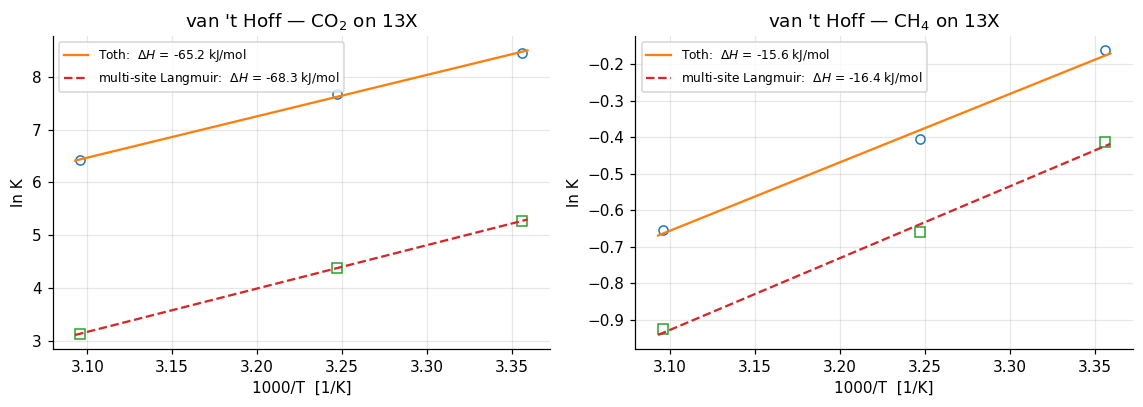

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8))
for ax, g in zip(axes, ['CO2', 'CH4']):
    for m, style in (('Toth', 'o-'), ('multi-site Langmuir', 's--')):
        v = vh[(g, m)]
        xx = np.linspace(v['x'].min() * 0.999, v['x'].max() * 1.001, 10)
        ax.plot(v['x'] * 1000, v['y'], style[0], ms=6, mfc='none')
        ax.plot(xx * 1000, v['slope'] * xx + v['lnK0'], style[1:], lw=1.5,
                label=f"{m}:  $\\Delta H$ = {v['dH_ads [kJ/mol]']:.1f} kJ/mol")
    ax.set(xlabel='1000/T  [1/K]', ylabel='ln K',
           title=f'van \'t Hoff — {"CO$_2$" if g=="CO2" else "CH$_4$"} on 13X')
    ax.legend(fontsize=8)
fig.tight_layout()

## Final answers

In [15]:
q2_out = q2[['qmax [mmol/g]', 'K [1/mmHg]', 'R2', 'AARD_%']].round(5)
print('Q2  Langmuir, CO2 at 25 C\n')
print(q2_out.to_string(), '\n')

print('Q3  zeolite 13X\n')
out = []
for g in gases:
    qmT, n, KT = toth_par[g]
    qmM, a, KM = msl_par[g]
    out.append({'gas': g, 'model': 'Toth', 'qmax [mol/kg]': qmT, 'n or a': n,
                **{f'K{T}': KT[T] for T in T_list},
                'dH_ads [kJ/mol]': vh[(g, 'Toth')]['dH_ads [kJ/mol]']})
    out.append({'gas': g, 'model': 'multi-site Langmuir', 'qmax [mol/kg]': qmM, 'n or a': a,
                **{f'K{T}': KM[T] for T in T_list},
                'dH_ads [kJ/mol]': vh[(g, 'multi-site Langmuir')]['dH_ads [kJ/mol]']})
print(pd.DataFrame(out).set_index(['gas', 'model']).round(4).to_string())

Q2  Langmuir, CO2 at 25 C

                  qmax [mmol/g]  K [1/mmHg]       R2   AARD_%
adsorbent                                                    
Activated carbon        2.63037     0.01450  0.94823  6.97079
Silica gel              2.97144     0.00137  0.99783  6.97023 

Q3  zeolite 13X

                         qmax [mol/kg]  n or a       K298       K308      K323  dH_ads [kJ/mol]
gas model                                                                                      
CO2 Toth                       10.6208  0.2442  4655.1189  2136.5790  612.7113         -65.1562
    multi-site Langmuir        10.6208  6.0799   193.4092    80.5472   22.9599         -68.2769
CH4 Toth                       10.0194  0.6114     0.8509     0.6665    0.5207         -15.5947
    multi-site Langmuir        10.0194  2.1667     0.6627     0.5165    0.3960         -16.3704


### What the numbers mean

**Tóth $n$.** $n_{CO_2}\approx0.24$ is far below 1 — CO₂ sees a very heterogeneous
energy landscape on 13X, because it binds to the extra-framework Na⁺ cations first
(strong, few) and to the rest of the cage afterwards (weak, many). $n_{CH_4}\approx0.61$ is
much closer to 1: non-polar CH₄ has no such preferred cation site, so the surface looks
comparatively uniform to it. This is precisely the heterogeneity that made plain Langmuir
fail on activated carbon in Q2.

**Multi-site $a$.** $a_{CH_4}\approx2.2$ against $a_{CO_2}\approx6.1$ — under this model
a CO₂ molecule ties up several sites, consistent with a linear quadrupolar molecule bridging
across cations, while CH₄ behaves nearly as a small compact adsorbate. (Remember $a$ was made
identifiable by pinning $q_{max}$; its absolute value should be read as a shape parameter,
not literally counted.)

**Δ$H_{ads}$.** Both models agree: about **−65 to −68 kJ/mol for CO₂** and
**−16 kJ/mol for CH₄** — the model choice changes the value by only a few per cent, which is
the real check that the fit is physically meaningful and not an artefact of one equation.
Both are negative: adsorption is exothermic, so loading falls as temperature rises, exactly
as the three isotherms show.

The four-fold difference in $|\Delta H_{ads}|$ is the whole basis of the separation:
CO₂'s quadrupole interacts strongly with the electric field of the Na⁺ cations in 13X,
CH₄ only through weak dispersion. This is why zeolite 13X is used for CO₂/CH₄ separation
(biogas upgrading, natural-gas sweetening) in PSA/TSA cycles — and the large $|\Delta H|$
for CO₂ is also why the bed heats up appreciably on adsorption, which is what a
non-isothermal adsorber model has to account for.

Both models fit the data well ($R^2>0.995$ throughout). Tóth is the better description of
CO₂ and is easier to use since it is explicit in $q$; the multi-site Langmuir has the
advantage of a thermodynamically consistent multicomponent extension.